# Lecture 4 – Pandas I: Series, DataFrames, and selection

QSS 20 · Modern Statistical Computing · Fall 2026

### Agenda

- Where today's data comes from, and what the numbers in it mean.
- A picture worth explaining.
- Columns: `Series` and `DataFrame`.
- Conditions: one decision per row.
- Selecting rows with `.loc`, and checking what you selected.

## 1. Where the data comes from

- Every time the House votes, the result is recorded: who voted yea, who voted
  nay, who abstained.
- Political scientists have collected every one of those votes since 1789.

- **Voteview** publishes them, along with a score for each member, at
  <https://voteview.com>.
- It is maintained by a team at UCLA, and it is where our file came from.

Here is the 112th House on Voteview, sorted by score. The column on the right
is the same number our file calls `dwnom1`.

![The 112th House roster on voteview.com, showing name, party, state, and NOMINATE score](images/voteview-house-112.jpg)

## What is a DW-NOMINATE score?

- Imagine placing every member of the House on a single line, from the most
  liberal on the left to the most conservative on the right.
- You do not know where anyone belongs. All you have is the voting record.

- Here is the idea. If two members almost always vote the same way, put them
  **close together**. If they almost always vote opposite ways, put them **far
  apart**.

- Now do that for all 440 members and all several hundred votes at once, and
  find the arrangement that gets the most votes right.
- Each member's position on that line is their score.

### How it is actually computed

- Each vote has two outcomes, yea and nay, and each sits somewhere on the line.
- A member is assumed to vote for whichever outcome is **closer to their own
  position**, most of the time.
- The procedure searches for the member positions and the vote positions that
  together predict the real votes with the fewest mistakes.

- Nobody assigns these numbers by reading speeches. They are **estimated** from
  behaviour.
- `dwnom1` is the first and strongest dimension. Historically it tracks
  disagreement about the role of government in the economy.
- `dwnom2` is a second dimension, historically race and civil rights. We set it
  aside today.
- The "DW" means the scores are put on one scale across time, so the 80th
  Congress and the 112th can be compared.

### What the score is not

- It is not an opinion poll, and it is not what a member believes.
- Two members with the same score **voted alike**. That is the whole claim.
- A member who votes with their party out of loyalty and one who votes with it
  out of conviction get the same number.

## 2. A picture worth explaining

Below, **one faint dot is one member of the House in one Congress**, placed at
the year they served and their score. The solid line is each party's median.

Read the code later if you like. For now, look at the picture.

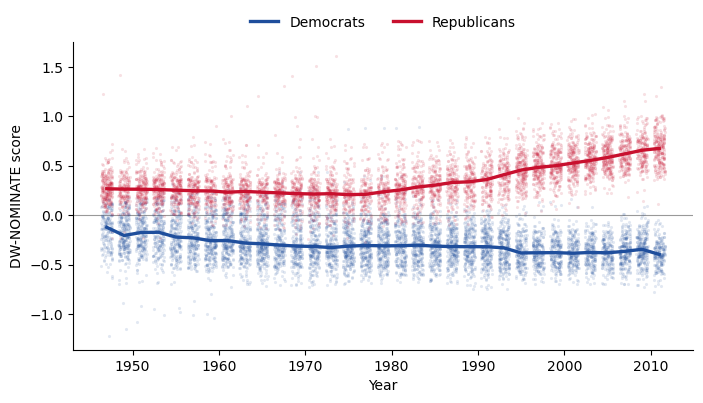

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 8)

congress = pd.read_csv('../../data/raw/congress.csv')

# You will be able to read every line of this by the end of next lecture.
members = congress.loc[congress['district'] != 0].copy()
members['year'] = 1789 + 2 * (members['congress'] - 1)
medians = members.groupby(['year', 'party'])['dwnom1'].median().unstack()

rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(8, 4))

# One dot per member. Everyone in a Congress shares a year, so the dots are
# nudged sideways a little to keep them from landing on top of each other.
for party, colour in [('Democrat', '#1f4e9c'), ('Republican', '#c8102e')]:
    side = members.loc[members['party'] == party]
    ax.scatter(side['year'] + rng.uniform(-0.65, 0.65, len(side)),
               side['dwnom1'], s=5, color=colour, alpha=0.13,
               linewidths=0, zorder=1)

for party, colour, label in [('Democrat', '#1f4e9c', 'Democrats'),
                             ('Republican', '#c8102e', 'Republicans')]:
    ax.plot(medians.index, medians[party], color=colour, linewidth=2.4,
            zorder=3, label=label)

ax.axhline(0, color='#999999', linewidth=0.8, zorder=0)
ax.set(xlabel='Year', ylabel='DW-NOMINATE score')
ax.legend(frameon=False, loc='lower center', bbox_to_anchor=(0.5, 1.0), ncol=2)
ax.spines[['top', 'right']].set_visible(False)
plt.show()

### ❓ Question

Before reading on, answer for yourself:

1. Did the two parties move apart, stay the same, or come together?
2. Did **both** move, or only one?
3. Roughly what year does the change start?
4. Look at the dots, not the lines. In 1947, is there a gap between the two
   parties? In 2011?

<details><summary>Answer</summary>

The parties move apart, and **asymmetrically**. The Democratic line drifts down
gently across the whole period. The Republican line is flat, even drifting
slightly left, until about **1975**, and then climbs steeply.

The dots add something the lines cannot show. In 1947 the two clouds **overlap**:
plenty of Democrats sit to the right of plenty of Republicans. By 2011 there is
clear air between them. We come back to that at the end of class.

</details>

## 3. Today's question

> **Did the two parties in the House move apart between 1947 and 2013, and did
> both parties move?**

The picture suggests an answer. Today we produce the numbers behind it, and to
do that we need one new skill: **choosing rows**.

## 4. The package we will use: pandas

- **pandas** is the standard Python library for working with tables.
- Underneath it sits **NumPy**, which does the fast numerical work. You will
  rarely call NumPy directly this term.

- The name comes from **panel data**: repeated observations on the same units
  over time.
- That is exactly our table. The same districts, observed across 33
  Congresses.

- The convention is `import pandas as pd`, and everyone writes `pd`. You will
  see it in every example online.

In [2]:
import pandas as pd

pd.__version__

'2.2.3'

- Two objects do almost all the work: the **DataFrame** and the **Series**.

## 5. The table

- One row is **one member of the House in one Congress**.
- A Congress lasts two years, so a member who served ten years appears five
  times.
- Numbered 80 (1947–49) through 112 (2011–13).

| Column | What it holds |
|---|---|
| `congress` | which Congress: 80 through 112 |
| `district` | the House district number |
| `state` | the state |
| `party` | Democrat, Republican, or Other |
| `name` | the member's surname |
| `dwnom1` | the score described above |
| `dwnom2` | the second dimension, set aside today |

In [3]:
congress

,congress,district,state,party,name,dwnom1,dwnom2
0,80,0,USA,Democrat,TRUMAN,-0.276,0.016
1,80,1,ALABAMA,Democrat,BOYKIN F.,-0.026,0.796
2,80,2,ALABAMA,Democrat,GRANT G.,-0.042,0.999
3,80,3,ALABAMA,Democrat,ANDREWS G.,-0.008,1.005
...,...,...,...,...,...,...,...
14548,112,6,WISCONS,Republican,PETRI,0.776,-0.003
14549,112,7,WISCONS,Republican,DUFFY,0.781,-0.270
14550,112,8,WISCONS,Republican,RIBBLE,0.886,-0.193
14551,112,1,WYOMING,Republican,LUMMIS,0.932,-0.211


- `.shape` gives (rows, columns). Check it after loading anything.
- The index on the left, 0, 1, 2, ..., is **not** a column.

In [4]:
congress.shape

(14552, 7)

- 14,552 rows: 33 Congresses of members stacked on top of each other.
- `.head(n)` and `.tail(n)` show the first and last rows.

In [5]:
congress.head(3)

,congress,district,state,party,name,dwnom1,dwnom2
0,80,0,USA,Democrat,TRUMAN,-0.276,0.016
1,80,1,ALABAMA,Democrat,BOYKIN F.,-0.026,0.796
2,80,2,ALABAMA,Democrat,GRANT G.,-0.042,0.999


In [6]:
congress.tail(3)

,congress,district,state,party,name,dwnom1,dwnom2
14549,112,7,WISCONS,Republican,DUFFY,0.781,-0.270
14550,112,8,WISCONS,Republican,RIBBLE,0.886,-0.193
14551,112,1,WYOMING,Republican,LUMMIS,0.932,-0.211


## 6. What's in a DataFrame

Almost everything in pandas is one of three things. Learn to name which one you
are holding.

- **DataFrame**: the whole table. Rows and columns.

![Anatomy of a DataFrame: the column names across the top, the index of row labels down the left, one highlighted row, and one highlighted column that is a Series](images/dataframe-anatomy.png)

In [7]:
congress.head(3)

,congress,district,state,party,name,dwnom1,dwnom2
0,80,0,USA,Democrat,TRUMAN,-0.276,0.016
1,80,1,ALABAMA,Democrat,BOYKIN F.,-0.026,0.796
2,80,2,ALABAMA,Democrat,GRANT G.,-0.042,0.999


- **Series**: a single column, with the row labels carried along.

In [8]:
congress['dwnom1'].head(3)

0   -0.276
1   -0.026
2   -0.042
Name: dwnom1, dtype: float64

- **Index**: the sequence of **row labels**, shown in bold down the left.

In [9]:
congress.index

RangeIndex(start=0, stop=14552, step=1)

- ⚠️ The index is **not a column**. `congress.shape` says 7 columns, and the
  index is not one of them.
- The column names are themselves an index, of the columns.

In [10]:
congress.columns

Index(['congress', 'district', 'state', 'party', 'name', 'dwnom1', 'dwnom2'], dtype='object')

- Our index here is just 0, 1, 2, ... because `read_csv` numbers the rows when
  the file gives it nothing better.
- Last lecture the *Federalist* table had essay numbers to use instead. This
  table has no natural label: surnames repeat.

In [11]:
congress['name'].value_counts().head(3)

name
DAVIS      44
MILLER     35
JOHNSON    29
Name: count, dtype: int64

- `DAVIS` appears 44 times. A label has to be unique to be useful, so we leave
  the numbers alone.

## 7. Getting a column

- Last lecture you used `.get('column')`.

In [12]:
congress.get('dwnom1')

0       -0.276
1       -0.026
2       -0.042
3       -0.008
         ...  
14548    0.776
14549    0.781
14550    0.886
14551    0.932
Name: dwnom1, Length: 14552, dtype: float64

- There is a second way, with square brackets.
- It is what you will see in almost every pandas example you will meet.

In [13]:
congress['dwnom1']

0       -0.276
1       -0.026
2       -0.042
3       -0.008
         ...  
14548    0.776
14549    0.781
14550    0.886
14551    0.932
Name: dwnom1, Length: 14552, dtype: float64

- Same result. From here on we use square brackets.

- What comes back is a **Series**: one column of values with the row labels
  attached.

In [14]:
type(congress['dwnom1'])

pandas.core.series.Series

In [15]:
congress

,congress,district,state,party,name,dwnom1,dwnom2
0,80,0,USA,Democrat,TRUMAN,-0.276,0.016
1,80,1,ALABAMA,Democrat,BOYKIN F.,-0.026,0.796
2,80,2,ALABAMA,Democrat,GRANT G.,-0.042,0.999
3,80,3,ALABAMA,Democrat,ANDREWS G.,-0.008,1.005
...,...,...,...,...,...,...,...
14548,112,6,WISCONS,Republican,PETRI,0.776,-0.003
14549,112,7,WISCONS,Republican,DUFFY,0.781,-0.270
14550,112,8,WISCONS,Republican,RIBBLE,0.886,-0.193
14551,112,1,WYOMING,Republican,LUMMIS,0.932,-0.211


- A **list** of column names gives you back a `DataFrame`, not a `Series`.

### ❓ Question

`congress['dwnom1']` gave you a `Series`. What does
`congress[['party', 'dwnom1']]` give, with a **list** inside the brackets?

<details><summary>Answer</summary>

A `DataFrame`. One name gives a single column, so a `Series`. A list of names
gives a table, so a `DataFrame`, even when the list holds only one name.

Run the next two cells and confirm it.

</details>

In [16]:
congress[['party', 'dwnom1']]

,party,dwnom1
0,Democrat,-0.276
1,Democrat,-0.026
2,Democrat,-0.042
3,Democrat,-0.008
...,...,...
14548,Republican,0.776
14549,Republican,0.781
14550,Republican,0.886
14551,Republican,0.932


In [17]:
type(congress[['party', 'dwnom1']])

pandas.core.frame.DataFrame

- 🤔 Even a list with one name gives a `DataFrame`.

In [18]:
type(congress[['dwnom1']])

pandas.core.frame.DataFrame

- One name → `Series`. A list of names → `DataFrame`.
- This matters: the two do not share all the same methods, and error messages
  will not tell you which one you are holding.

### More things to ask a Series

- The comment is the question. The code is the answer.

In [19]:
# What parties appear in this file?
congress['party'].unique()

array(['Democrat', 'Republican', 'Other'], dtype=object)

In [20]:
# How many distinct parties is that?
congress['party'].nunique()

3

In [21]:
# How many members of each?
congress['party'].value_counts()

party
Democrat      8132
Republican    6401
Other           19
Name: count, dtype: int64

In [22]:
# The middle of the distribution, less pulled around by extremes than the mean.
congress['dwnom1'].median()

-0.0450000017881393

In [23]:
# Lots of information at once.
congress['dwnom1'].describe()

count    14552.000000
mean        -0.001731
std          0.383772
min         -1.220000
25%         -0.329000
50%         -0.045000
75%          0.296000
max          1.611000
Name: dwnom1, dtype: float64

- Sorting a `Series` needs no column name, because there is only one column.
- Sorting a `DataFrame` does: `congress.sort_values('dwnom1')`.

In [24]:
congress['dwnom1'].sort_values().head(3)

260    -1.220
702    -1.149
1143   -1.079
Name: dwnom1, dtype: float64

- `.idxmax()` gives the **row label** of the largest value, not the value
  itself.
- That label is what you feed to `.loc` to get the whole row.

In [25]:
congress['dwnom1'].idxmax()

5876

In [26]:
congress.loc[congress['dwnom1'].idxmax()]

congress            93
district             3
state             IOWA
party       Republican
name           GROSS H
dwnom1           1.611
dwnom2           0.461
Name: 5876, dtype: object

- The most conservative score in the file belongs to Representative Gross of
  Iowa, at 1.611.

## 8. Series do arithmetic, one element at a time

- Multiply a `Series` by a number and every entry changes at once. No loop.

In [27]:
x = pd.Series({'a': 1, 'b': 2})
x * 5

a     5
b    10
dtype: int64

- Add two Series and pandas matches them up **by index label**, not by
  position.

In [28]:
y = pd.Series({'b': 5, 'c': -1, 'a': 10})
x + y

a    11.0
b     7.0
c     NaN
dtype: float64

- `a` and `b` appear in both, so they add.
- `c` appears in only one, so the answer is `NaN`: "not a number", pandas's
  missing value.
- Notice it did not line them up in the order you typed them. Labels decide.

- On the real table: `dwnom1` runs about -1 to +1. Rescale it to roughly -100
  to +100 in one expression.

In [29]:
(congress['dwnom1'] * 100).head(3)

0   -27.599999
1    -2.600000
2    -4.200000
Name: dwnom1, dtype: float64

## 9. Method chaining

- Most pandas methods return a new object, so you can hang the next call
  straight off the end.
- Read a chain **left to right**: each step takes what the step before produced.

In [30]:
congress['party'].value_counts().idxmax()

'Democrat'

- Three steps: take the column, count each value, report the label of the
  largest count.
- A longer one. Wrap it in parentheses and put one call per line, which is how
  you will write these in practice.

In [31]:
(
    congress
    .loc[congress['congress'] == 112]
    .sort_values('dwnom1', ascending=False)
    .head(10)
    ['state']
    .value_counts()
)

state
CALIFOR    2
TEXAS      1
WISCONS    1
ARIZONA    1
          ..
MICHIGA    1
ILLINOI    1
IDAHO      1
GEORGIA    1
Name: count, Length: 9, dtype: int64

- Step by step: the whole table, keep the 112th Congress, sort most
  conservative first, take the top ten, pull out their states, count them.
- Build a chain one line at a time and look at the output after each line. Do
  not write six steps and then try to debug them at once.

## 10. The first thing you might try, and why it fails

- We want to know whether the parties moved apart.
- We have a column that measures where members sit. So: take its average.
- That is the cell you just ran: **-0.002**. Almost exactly zero.

- The number is meaningless:
  - It averages 33 Congresses and both parties at once.
  - Liberals and conservatives cancel; 1947 and 2013 are mixed together.

- It describes no Congress and no party.
- To say anything, we have to **choose certain rows first**.

## 11. A condition makes one decision per row

In [32]:
congress

,congress,district,state,party,name,dwnom1,dwnom2
0,80,0,USA,Democrat,TRUMAN,-0.276,0.016
1,80,1,ALABAMA,Democrat,BOYKIN F.,-0.026,0.796
2,80,2,ALABAMA,Democrat,GRANT G.,-0.042,0.999
3,80,3,ALABAMA,Democrat,ANDREWS G.,-0.008,1.005
...,...,...,...,...,...,...,...
14548,112,6,WISCONS,Republican,PETRI,0.776,-0.003
14549,112,7,WISCONS,Republican,DUFFY,0.781,-0.270
14550,112,8,WISCONS,Republican,RIBBLE,0.886,-0.193
14551,112,1,WYOMING,Republican,LUMMIS,0.932,-0.211


- Start with the comparison on its own, before selecting anything.

In [33]:
congress['congress'] == 80

0         True
1         True
2         True
3         True
         ...  
14548    False
14549    False
14550    False
14551    False
Name: congress, Length: 14552, dtype: bool

- A Series the same length as the table, holding `True` or `False`.
- pandas compared **every row** to 80 and recorded the answer.
- We call this a **mask**.

- A mask is not a table of members. It is a column of decisions, one per row.

In [34]:
type(congress['congress'] == 80)

pandas.core.series.Series

### ❓ Question

`True` counts as 1 and `False` counts as 0 in Python. So before you run the
next cell, what will it print?

```python
(congress['congress'] == 80).sum()
```

Is it a count of something? Of what?

<details><summary>Answer</summary>

It counts the rows where the condition is `True`, so it is the **number of rows
belonging to the 80th Congress**. Summing a mask is how you find out what a
condition would select, before you select anything.

A common wrong answer is 80, or the sum of the `congress` column. The mask no
longer holds Congress numbers; it holds one yes-or-no per row.

</details>

In [35]:
(congress['congress'] == 80).sum()

446

- 446 rows belong to the 80th Congress.
- Summing a mask counts what a condition would select. Do this **before** you
  select, as a cheap check.

## 12. Keeping rows with `.loc`

In [36]:
congress

,congress,district,state,party,name,dwnom1,dwnom2
0,80,0,USA,Democrat,TRUMAN,-0.276,0.016
1,80,1,ALABAMA,Democrat,BOYKIN F.,-0.026,0.796
2,80,2,ALABAMA,Democrat,GRANT G.,-0.042,0.999
3,80,3,ALABAMA,Democrat,ANDREWS G.,-0.008,1.005
...,...,...,...,...,...,...,...
14548,112,6,WISCONS,Republican,PETRI,0.776,-0.003
14549,112,7,WISCONS,Republican,DUFFY,0.781,-0.270
14550,112,8,WISCONS,Republican,RIBBLE,0.886,-0.193
14551,112,1,WYOMING,Republican,LUMMIS,0.932,-0.211


- `.loc[...]` takes a mask and returns the rows where it is `True`.

### ❓ Question

The mask has 446 `True` values. So how many **rows** will
`congress.loc[...]` return, and how many **columns**?

<details><summary>Answer</summary>

446 rows and 7 columns. `.loc` with a mask keeps rows and touches nothing else,
so the column count never changes.

If you get a different row count than the mask promised, the condition is not
the one you thought you wrote.

</details>

In [37]:
congress.loc[congress['congress'] == 80]

,congress,district,state,party,name,dwnom1,dwnom2
0,80,0,USA,Democrat,TRUMAN,-0.276,0.016
1,80,1,ALABAMA,Democrat,BOYKIN F.,-0.026,0.796
2,80,2,ALABAMA,Democrat,GRANT G.,-0.042,0.999
3,80,3,ALABAMA,Democrat,ANDREWS G.,-0.008,1.005
...,...,...,...,...,...,...,...
442,80,8,WISCONS,Republican,BYRNES J.,0.370,-0.456
443,80,9,WISCONS,Republican,HULL M.,0.028,-0.456
444,80,10,WISCONS,Republican,O'KONSKI,0.124,-0.043
445,80,1,WYOMING,Republican,BARRETT F.,0.304,-0.110


- Read it left to right: from `congress`, keep the rows where the `congress`
  column equals 80.
- The inner part is the decision. `.loc` is what acts on it.

In [38]:
# 446 rows, as the mask promised. Still 7 columns.
congress.loc[congress['congress'] == 80].shape

(446, 7)

## 13. Two conditions

- You might expect this to work. Run it and read the error.

### ❓ Question

You want members who are both in the 80th Congress **and** Democrats. The
obvious line is below.

```python
congress['congress'] == 80 and congress['party'] == 'Democrat'
```

Will it give you the rows you want, give you the wrong rows, or fail?

<details><summary>Answer</summary>

It fails, with a `ValueError`. Run the next cell and read the message.

The reason is worth knowing: `and` expects **two** single true-or-false values.
Each side here is a column of 14,552 decisions, and Python will not guess
whether you meant "all of them" or "any of them".

</details>

In [39]:
congress['congress'] == 80 and congress['party'] == 'Democrat'

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

- When Python gives you an error, **the most useful line is usually the last
  one**.
- `ValueError: The truth value of a Series is ambiguous.`

### Why `and` cannot do this

- `and` has one job: take **two** yes-or-no answers and return **one**.

In [40]:
True and False

False

- To do that, `and` first has to ask "is the left side yes or no?"
- For a single value that is easy. For a whole **collection** of values, it is
  not obvious what the answer should be.

- Watch what plain Python does when you give `and` two lists.

In [41]:
[True, True] and [False, True]

[False, True]

In [42]:
[] and [False, True]

[]

In [43]:
help("and")

Boolean operations
******************

   or_test  ::= and_test | or_test "or" and_test
   and_test ::= not_test | and_test "and" not_test
   not_test ::= comparison | "not" not_test

In the context of Boolean operations, and also when expressions are
used by control flow statements, the following values are interpreted
as false: "False", "None", numeric zero of all types, and empty
strings and containers (including strings, tuples, lists,
dictionaries, sets and frozensets).  All other values are interpreted
as true.  User-defined objects can customize their truth value by
providing a "__bool__()" method.

The operator "not" yields "True" if its argument is false, "False"
otherwise.

The expression "x and y" first evaluates *x*; if *x* is false, its
value is returned; otherwise, *y* is evaluated and the resulting value
is returned.

The expression "x or y" first evaluates *x*; if *x* is true, its value
is returned; otherwise, *y* is evaluated and the resulting value is
returned.

Note 

- No error, but look closely: it did **not** combine them.
- It decided the first list counted as "yes" (since it is not empty), so it handed
  back the second list untouched.

### What `&` does instead

- `&` never asks "is this whole column yes or no?"
- It lines the two columns up side by side and answers **once per row**.

In [44]:
left = pd.Series([True, True, False, False])
right = pd.Series([True, False, True, False])

pd.DataFrame({'left': left, 'right': right,
              'left & right': left & right,
              'left | right': left | right,
              '~left': ~left})

,left,right,left & right,left | right,~left
0,True,True,True,True,False
1,True,False,False,True,False
2,False,True,False,True,True
3,False,False,False,False,True


- Read any row across: `&` gives `True` only when both sides are `True`.
- `|` gives `True` when either side is.
- `~` flips a column.

**The whole difference in one line:**

- `and` **collapses** a column into a single answer, then combines.
- `&` **keeps** one answer per row.

You want one decision per member, so you want `&`.

| Operator | Meaning | Use it when |
|---|---|---|
| `and`, `or`, `not` | combine two single answers | comparing two numbers or strings |
| `&`, `\|`, `~` | combine two columns, row by row | filtering a DataFrame |

### ⚠️ Every condition needs its own parentheses

- `&` binds **more tightly** than `==`, the way `*` binds more tightly
  than `+`.
- So `congress['congress'] == 80 & congress['party'] == 'Democrat'` is read by
  Python as `congress['congress'] == (80 & congress['party']) == 'Democrat'`,
  which is nonsense.

In [45]:
# `&` on two plain numbers is a bit-by-bit operation, which is why
# Python is willing to try `80 & something` first.
1 & 2

0

- The fix is always the same: wrap each condition in its own brackets.

In [46]:
(congress['congress'] == 80) & (congress['party'] == 'Democrat')

0         True
1         True
2         True
3         True
         ...  
14548    False
14549    False
14550    False
14551    False
Length: 14552, dtype: bool

In [47]:
congress.loc[(congress['congress'] == 80) & (congress['party'] == 'Democrat')]

,congress,district,state,party,name,dwnom1,dwnom2
0,80,0,USA,Democrat,TRUMAN,-0.276,0.016
1,80,1,ALABAMA,Democrat,BOYKIN F.,-0.026,0.796
2,80,2,ALABAMA,Democrat,GRANT G.,-0.042,0.999
3,80,3,ALABAMA,Democrat,ANDREWS G.,-0.008,1.005
...,...,...,...,...,...,...,...
422,80,9,VIRGINI,Democrat,FLANNAGAN,-0.162,0.555
424,80,2,WASHING,Democrat,JACKSON H.,-0.331,-0.114
433,80,5,WEST VI,Democrat,KEE J.,-0.320,-0.055
434,80,6,WEST VI,Democrat,HEDRICK E.,-0.144,-0.011


## 14. Check what you selected

- A selection that runs is not a selection that is right.
- Give it a name, then ask it what it contains.

In [48]:
dem80 = congress.loc[(congress['congress'] == 80) & (congress['party'] == 'Democrat')]
dem80.shape

(194, 7)

In [49]:
# Only one Congress should appear.
dem80['congress'].unique()

array([80])

In [50]:
# And only one party.
dem80['party'].unique()

array(['Democrat'], dtype=object)

- One Congress, one party, 194 rows. Now an average means something.

In [51]:
dem80['dwnom1'].mean()

-0.14558247413627862

<div class="alert alert-success">

### Activity 1 · Two of these are wrong

You want **Democrats who served in either the 80th or the 112th Congress**.

Here are three attempts. Exactly one is right.

```python
# A
congress.loc[(congress['party'] == 'Democrat')
             & (congress['congress'] == 80)
             | (congress['congress'] == 112)]

# B
congress.loc[(congress['party'] == 'Democrat')
             & ((congress['congress'] == 80)
                | (congress['congress'] == 112))]

# C
congress.loc[congress['party'] == 'Democrat'
             & (congress['congress'].isin([80, 112]))]
```

Decide **without running anything**:

1. Which one is correct?
2. For each wrong one, what does it actually do? One raises an error; say which
   and why. The other returns a table; say what is in it that should not be.

Then run them in the empty cell below and check the row counts and the unique
values of `party` and `congress`.

</div>

- **B** is correct: 394 rows, Democrats only, Congresses 80 and 112.

In [52]:
B = congress.loc[(congress['party'] == 'Democrat')
                 & ((congress['congress'] == 80) | (congress['congress'] == 112))]
print(B.shape[0], B['party'].unique(), sorted(B['congress'].unique()))

394 ['Democrat'] [80, 112]


- **A** runs and gives 637 rows. `&` binds tighter than `|`, so Python read it
  as `(Democrat AND 80th) OR (112th)`.
- That second half has no party condition, so **every Republican in the 112th
  came along**.

In [53]:
A = congress.loc[(congress['party'] == 'Democrat') & (congress['congress'] == 80)
                 | (congress['congress'] == 112)]
print(A.shape[0], A['party'].unique(), sorted(A['congress'].unique()))

637 ['Democrat' 'Republican'] [80, 112]


- **C** raises a `TypeError`. The condition `congress['party'] == 'Democrat'`
  has no parentheses, and `&` binds tighter than `==`, so Python tried
  `'Democrat' & (a column of True/False)` first.

- A is the dangerous one. It raises nothing, returns a plausible-looking table,
  and quietly answers a different question.
- Parentheses around **every** condition, and around each group of them.

## 15. Rows and columns at once

- `.loc` takes two arguments: which rows, then which columns.

In [54]:
congress.loc[congress['congress'] == 80, ['name', 'state', 'dwnom1']]

,name,state,dwnom1
0,TRUMAN,USA,-0.276
1,BOYKIN F.,ALABAMA,-0.026
2,GRANT G.,ALABAMA,-0.042
3,ANDREWS G.,ALABAMA,-0.008
...,...,...,...
442,BYRNES J.,WISCONS,0.370
443,HULL M.,WISCONS,0.028
444,O'KONSKI,WISCONS,0.124
445,BARRETT F.,WYOMING,0.304


- One column name instead of a list gives a `Series` again.

In [55]:
congress.loc[congress['congress'] == 80, 'dwnom1']

0     -0.276
1     -0.026
2     -0.042
3     -0.008
       ...  
442    0.370
443    0.028
444    0.124
445    0.304
Name: dwnom1, Length: 446, dtype: float64

## 16. `.loc` is more flexible than it looks

- So far we have fed `.loc` a mask. It also takes labels.

- One row label and one column label gives a single value.

In [56]:
congress.loc[5, 'name']

'RAINS  A.'

- A list of row labels and a list of column labels gives a table.

In [57]:
congress.loc[[0, 1, 2], ['name', 'state', 'dwnom1']]

,name,state,dwnom1
0,TRUMAN,USA,-0.276
1,BOYKIN F.,ALABAMA,-0.026
2,GRANT G.,ALABAMA,-0.042


- ⚠️ A **slice** of labels includes **both** endpoints, unlike ordinary Python
  slicing.

In [58]:
congress.loc[0:3, 'state':'dwnom1']

,state,party,name,dwnom1
0,USA,Democrat,TRUMAN,-0.276
1,ALABAMA,Democrat,BOYKIN F.,-0.026
2,ALABAMA,Democrat,GRANT G.,-0.042
3,ALABAMA,Democrat,ANDREWS G.,-0.008


- Four rows, 0 through 3, and every column from `state` to `dwnom1`.
- Plain Python would have stopped before 3.

- Row labels alone, with no column argument, keeps every column.

In [59]:
congress.loc[[0, 1]]

,congress,district,state,party,name,dwnom1,dwnom2
0,80,0,USA,Democrat,TRUMAN,-0.276,0.016
1,80,1,ALABAMA,Democrat,BOYKIN F.,-0.026,0.796


## 17. `.iloc` counts positions instead

![The same table twice. On the left, .loc with a label slice from 0 to 2 keeps three rows. On the right, .iloc with a position slice from 0 to 2 keeps two rows, because the end is excluded](images/loc-iloc-slicing.png)

- `.loc` asks for **labels**. `.iloc` asks for **positions**, counting from 0.
- With this table the two look alike, because the labels happen to be 0, 1, 2,
  ... That is a coincidence of how the file was loaded.

In [60]:
congress.iloc[0:3, 0:2]

,congress,district
0,80,0
1,80,1
2,80,2


- Three rows, not four: `.iloc` **excludes** the end, the way Python slicing
  always does.
- Negative positions count from the right. `:-2` means every column except the
  last two.

In [61]:
congress.iloc[1:5, :-2]

,congress,district,state,party,name
1,80,1,ALABAMA,Democrat,BOYKIN F.
2,80,2,ALABAMA,Democrat,GRANT G.
3,80,3,ALABAMA,Democrat,ANDREWS G.
4,80,4,ALABAMA,Democrat,HOBBS S.


### Where the two come apart

- Sort the table. The rows move; their **labels move with them**.

In [62]:
ordered = congress.sort_values('dwnom1', ascending=False)
ordered.head(3)

,congress,district,state,party,name,dwnom1,dwnom2
5876,93,3,IOWA,Republican,GROSS H,1.611,0.461
5426,92,3,IOWA,Republican,GROSS H,1.509,0.374
746,81,8,OHIO,Republican,SMITH F.,1.416,-0.269


- 🤔 Now `.iloc[0]` and `.loc[0]` are different rows. Which is which?

In [63]:
print('position 0:', ordered['name'].iloc[0])
print('label 0:   ', ordered['name'].loc[0])

position 0: GROSS H
label 0:    TRUMAN


- `.iloc[0]` is the **top row of the sorted table**, the most conservative
  member.
- `.loc[0]` is still the row that was labelled 0 when the file loaded, which is
  Truman, now sitting somewhere in the middle.
- This is why the index is not a row number.

## 18. The row unit bites back

- We said one row is one member of the House in one Congress.
- Check that.

In [64]:
congress['district'].min()

0

- District 0. There is no district 0.
- Look at those rows.

In [65]:
congress.loc[congress['district'] == 0, ['congress', 'state', 'party', 'name']].head()

,congress,state,party,name
0,80,USA,Democrat,TRUMAN
446,81,USA,Democrat,TRUMAN
885,82,USA,Democrat,TRUMAN
1329,83,USA,Republican,EISENHOWER
1765,84,USA,Republican,EISENHOWER


In [66]:
congress.loc[congress['district'] == 0, 'name'].unique()

array(['TRUMAN', 'EISENHOWER', 'KENNEDY', 'JOHNSON', 'NIXON', 'FORD',
       'CARTER', 'REAGAN', 'BUSH', 'CLINTON', 'OBAMA'], dtype=object)

- Those are **presidents**, not House members.
- The file scores each president on the same scale, with `district` set to 0
  and `state` set to `'USA'`. There are 35 such rows.

- So our description of the row unit was wrong for 35 rows.
- And our count of 194 Democrats in the 80th included Harry Truman.

- `!=` means "not equal to".

In [67]:
house = congress.loc[congress['district'] != 0]

print('all rows: ', congress.shape[0])
print('House only:', house.shape[0])

all rows:  14552
House only: 14517


In [68]:
dem80_house = house.loc[(house['congress'] == 80) & (house['party'] == 'Democrat')]

print('Democrats in the 80th, House only:', dem80_house.shape[0])
print('mean dwnom1:', round(dem80_house['dwnom1'].mean(), 4))

Democrats in the 80th, House only: 193
mean dwnom1: -0.1449


- 193, not 194. The mean moved by less than 0.001.

- Sit with that. The mistake changed the answer so little that no output would
  ever have looked wrong.
- You would have published a number labelled "House Democrats" that quietly
  included a president.

- The defence is not checking whether the code ran.
- It is knowing what one row is.

## 19. Two shortcuts you will use constantly

### `.isin(list)`

- To keep several states you could write
  `(state == 'GEORGIA') | (state == 'ALABAMA') | ...`
- `.isin()` says it once.

In [69]:
south = ['ALABAMA', 'GEORGIA', 'LOUISIANA', 'MISSISSIPPI', 'SOUTH CAROLINA']
house.loc[house['state'].isin(south)].shape

(608, 7)

In [70]:
house['state'].unique()[:12]

array(['ALABAMA', 'ARIZONA', 'ARKANSA', 'CALIFOR', 'COLORAD', 'CONNECT',
       'DELAWAR', 'FLORIDA', 'GEORGIA', 'IDAHO', 'ILLINOI', 'INDIANA'],
      dtype=object)

- The state names are cut to seven characters.
- `'LOUISIANA'`, `'MISSISSIPPI'` and `'SOUTH CAROLINA'` never matched anything.
- Three of our five conditions did nothing, and nothing warned us.

In [71]:
south = ['ALABAMA', 'GEORGIA', 'LOUISIA', 'MISSISS', 'SOUTH C']
house.loc[house['state'].isin(south)].shape

(1245, 7)

- 1,245 rows, twice as many.
- Look at the values in a column **before** you filter on them. `.unique()` is
  how.

### `.between(low, high)`

- For a range. It includes **both** endpoints.

In [72]:
mid = house.loc[house['congress'].between(95, 100)]
print('rows:', mid.shape[0])
print('congresses kept:', sorted(mid['congress'].unique()))

rows: 2626
congresses kept: [95, 96, 97, 98, 99, 100]


<div class="alert alert-success">

### Activity 2 · Do the parties still overlap?

The party averages moved apart. That does not tell us whether the parties still
*share any ground*. In 1947 plenty of Democrats voted to the right of plenty of
Republicans. Is that still true in 2011?

For the **112th Congress**, using `house`, find:

1. The **most conservative Democrat**: the Democrat with the highest `dwnom1`.
   Report their name and score.
2. The **most liberal Republican**: the Republican with the lowest `dwnom1`.
   Report their name and score.
3. Then answer with code: how many Republicans sit to the **left** of that
   Democrat? How many Democrats sit to the **right** of that Republican?

Then repeat step 3 for the **80th Congress** and compare.

You will need `.sort_values()` and `.iloc[0]` from last lecture, plus today's
selection and `.sum()`.

</div>

In [73]:
top_dem = house.loc[(house['congress'] == 112) & (house['party'] == 'Democrat')] \
                    .sort_values('dwnom1', ascending=False).iloc[0]
top_rep = house.loc[(house['congress'] == 112) & (house['party'] == 'Republican')] \
                    .sort_values('dwnom1').iloc[0]
print('most conservative Democrat:', top_dem['name'], round(top_dem['dwnom1'], 3))
print('most liberal Republican:  ', top_rep['name'], round(top_rep['dwnom1'], 3))

for c in [112, 80]:
    one = house.loc[house['congress'] == c]
    d = one.loc[one['party'] == 'Democrat']
    r = one.loc[one['party'] == 'Republican']
    print(f"Congress {c}: Republicans left of the top Democrat:",
          (r['dwnom1'] < d['dwnom1'].max()).sum(),
          '| Democrats right of the leftmost Republican:',
          (d['dwnom1'] > r['dwnom1'].min()).sum())

most conservative Democrat: SHULER -0.048
most liberal Republican:   JONES 0.107
Congress 112: Republicans left of the top Democrat: 0 | Democrats right of the leftmost Republican: 0
Congress 80: Republicans left of the top Democrat: 121 | Democrats right of the leftmost Republican: 134


- In the **112th**, both counts are **zero**. Every Republican sits to the
  right of every Democrat. The two parties do not overlap at all.
- In the **80th**, the counts are 121 and 134. More than half of each party sat
  inside the other party's range.

That is a different fact from the averages, and a stronger one.

## 20. Answering the question

- Take the first Congress in the file and the last.
- Split each by party. Compare.

In [74]:
for c in [80, 112]:
    one = house.loc[house['congress'] == c]
    dem = one.loc[one['party'] == 'Democrat', 'dwnom1'].mean()
    rep = one.loc[one['party'] == 'Republican', 'dwnom1'].mean()
    print(f'Congress {c}:  Democrats {dem:+.3f}   Republicans {rep:+.3f}   gap {rep - dem:.3f}')

Congress 80:  Democrats -0.145   Republicans +0.276   gap 0.421
Congress 112:  Democrats -0.394   Republicans +0.675   gap 1.070


### The answer

- In the 80th Congress (1947–49) the gap between the party averages was
  **0.42**. In the 112th (2011–13) it was **1.07**.
- The distance grew by a factor of about 2.5.

- And **both** parties moved.
- Democrats went from -0.145 to -0.394, a move of 0.25 toward the liberal end.
- Republicans went from +0.276 to +0.675, a move of 0.40 toward the
  conservative end.

- Republicans moved about 1.6 times as far.
- That is sharper than "Congress is polarized". It says the gap widened, that
  neither side stayed put, and which side moved more.

### What this does not say

- `dwnom1` comes from **roll-call votes**, not beliefs or speeches. Two members
  with the same score voted alike. That is all it means.

- The scores are anchored so Congresses can be compared. That anchoring is a
  modelling choice made by the people who built the measure.

- This is the **House only**, and only members who cast enough votes to be
  scored. Members who died or resigned early can be missing.

- Nothing here says **why** the gap grew. Redistricting, primaries, the
  realignment of the South, and party leadership all have supporters in the
  literature. Selection cannot choose between them.

## Summary

| Goal | Write |
|---|---|
| One column, as a Series | `df['col']` |
| Several columns, as a DataFrame | `df[['a', 'b']]` |
| Distinct values · how many · counts | `.unique()` · `.nunique()` · `.value_counts()` |
| Summaries | `.mean()` `.median()` `.describe()` |
| Label of the largest value | `.idxmax()` |
| One decision per row | `df['col'] == value` |
| Count what a condition selects | `(df['col'] == value).sum()` |
| Keep matching rows | `df.loc[mask]` |
| Rows and columns together | `df.loc[mask, ['a', 'b']]` |
| One cell, by label | `df.loc[row_label, 'col']` |
| A slice of labels, **ends included** | `df.loc[0:3, 'a':'c']` |
| By position, **end excluded** | `df.iloc[0:3, 0:2]` |
| Both conditions · either · not | `&` · `\|` · `~` |
| One of several values | `df['col'].isin([...])` |
| Inside a range, endpoints included | `df['col'].between(lo, hi)` |

### Three habits

1. Every condition gets its own parentheses. Use `&` and `|`, never `and` or
   `or`.
2. After selecting, print the row count and the unique values of what you
   filtered on. A wrong selection usually runs without complaint.
3. Know what one row is before you report how many rows you have.

### What's next

- Today you compared two Congresses by hand. There are 33.
- Next lecture: ask for every group at once, with `groupby`.